<a href="https://colab.research.google.com/github/2020-byte/Hello-Deep-Learning/blob/main/mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# MNIST 데이터셋 불러오기
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 데이터 정규화
x_train, x_test = x_train / 255.0, x_test / 255.0

# 모델 만들기
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(x_train, y_train, epochs=5)

# 모델 저장 (Keras 형식)
model.save('my_model.keras')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8579 - loss: 0.4900
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9550 - loss: 0.1523
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9664 - loss: 0.1103
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9731 - loss: 0.0881
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9769 - loss: 0.0744


In [9]:
# 모델 저장 (Keras 형식)
model.save('my_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
예측된 숫자: 7
실제 숫자: 7


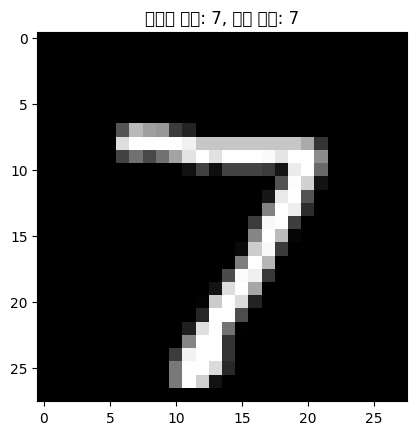

In [14]:
import matplotlib.pyplot as plt

# Keras 형식으로 저장된 모델 불러오기
model = tf.keras.models.load_model('my_model.keras')

# 인덱스를 변수로 설정
index = 0  # 예시로 1번 인덱스를 선택

# 테스트 데이터에서 해당 인덱스의 이미지와 실제 레이블 선택
image = x_test[index]
true_label = y_test[index]

# 예측: 이미지를 (1, 28, 28, 1) 형태로 reshape (배치 차원 추가 및 채널 차원 추가)
prediction = model.predict(image.reshape(1, 28, 28, 1))

# 예측된 레이블 (가장 확률이 높은 값)
predicted_label = prediction.argmax()

# 예측 결과 출력
print(f"예측된 숫자: {predicted_label}")
print(f"실제 숫자: {true_label}")

# 이미지 출력
plt.imshow(image, cmap='gray')
plt.title(f"예측된 숫자: {predicted_label}, 실제 숫자: {true_label}")
plt.show()